In [12]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier

In [2]:
df = pd.read_csv("substancias_remineralizadoras.csv")

print("Formato do dataset:", df.shape)
df.head()

Formato do dataset: (109, 57)


,Autor,Ano,Substancia 1,Substancia 2,Substancia 3,Substância 4,Substancia 5,Concentração substancia 1,Concentração substancia 2,Concentração substancia 3,...,Area_de_superficie_polar,Teste_microdureza,Tempo Teste EDX (dias),Teste_EDX,Tempo microscopia (dias),Microscopia_eletrônica (micrometros) µm²,Microscopia_eletrônica (classificação),Mineraliza ou não,Doi,Justificativa
0,"Goldberg, Michel et al.",2011,colageno_tipo_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,https://pmc.ncbi.nlm.nih.gov/articles/PMC3360947/,NaN
1,"Goldberg, Michel et al.",2011,colageno_tipo_3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
2,"Goldberg, Michel et al.",2011,hidroxiapatita,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,556.5,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
3,"Goldberg, Michel et al.",2011,glicoproteina_Da_dentina,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
4,"Goldberg, Michel et al.",2011,sialoproteina_ossea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN


In [3]:
target = "Mineraliza ou não"

print(df[target].value_counts())
print(df[target].value_counts(normalize=True))

Mineraliza ou não
1    72
0    37
Name: count, dtype: int64
Mineraliza ou não
1    0.66055
0    0.33945
Name: proportion, dtype: float64


In [4]:
target = "Mineraliza ou não"

colunas_remover = [
    target,
    "Autor",
    "Ano",
    "Doi",
    "Justificativa",

    # Colunas ligadas a resultados experimentais
    "Teste_microdureza",
    "Tempo Teste EDX (dias)",
    "Teste_EDX",
    "Tempo microscopia (dias)",
    "Microscopia_eletrônica (micrometros) µm²",
    "Microscopia_eletrônica (classificação)"
]

colunas_existentes_para_remover = [
    col for col in colunas_remover if col in df.columns
]

X = df.drop(columns=colunas_existentes_para_remover)
y = df[target].astype(int)

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (109, 46)
Formato de y: (109,)


In [6]:
colunas_numericas = X.select_dtypes(include=["number"]).columns.tolist()

colunas_categoricas = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("Quantidade de colunas numéricas:", len(colunas_numericas))
print("Quantidade de colunas categóricas:", len(colunas_categoricas))

print("\nColunas numéricas:")
print(colunas_numericas)

print("\nColunas categóricas:")
print(colunas_categoricas)

Quantidade de colunas numéricas: 8
Quantidade de colunas categóricas: 38

Colunas numéricas:
['Concentração g substancia 1', 'Frequencia de aplicação/dia', 'Tempo de aplicação (min)', 'Numero de aminoacidos', 'pH', 'Aceptores_de_ligacoes_de_hidrogenio', 'Doadores_de_ligacoes_de_hidrogenio', 'Area_de_superficie_polar']

Colunas categóricas:
['Substancia 1', 'Substancia 2', 'Substancia 3', 'Substância 4', 'Substancia 5', 'Concentração substancia 1', 'Concentração substancia 2', 'Concentração substancia 3', 'Concentração substancia 4', 'Concentração substancia 5', 'Porcentagem substancia 1', 'Porcentagem substancia 2', 'Concentração Composição 1', 'Composição 1', 'Concentração Composição 2', 'Composição 2', 'Concentração Composição 3', 'Composição 3', 'Concentração comp 4', 'Composição 4', 'Concentração comp 5', 'Composição 5', 'Concentração comp 6', 'Composição 6', 'Composição 7', 'Composição 8', 'Composição 9', 'Composição 10', 'Composição 11', 'Composição 12', 'Composição 13', 'Composi

In [7]:
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessamento = ColumnTransformer(
    transformers=[
        ("numericas", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), colunas_numericas),

        ("categoricas", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="constant", fill_value="Não informado")),
            ("onehot", onehot)
        ]), colunas_categoricas)
    ]
)

In [11]:
%pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.2/101.7 MB 2.8 MB/s eta 0:00:37
   ---------------------------------------- 0.4/101.7 MB 3.8 MB/s eta 0:00:27
   ---------------------------------------- 0.6/101.7 MB 3.8 MB/s eta 0:00:27
   ---------------------------------------- 0.8/101.7 MB 3.8 MB/s eta 0:00:27
   ---------------------------------------- 1.0/101.7 MB 4.0 MB/s eta 0:00:26
   ---------------------------------------- 1.1/101.7 MB 3.8 MB/s eta 0:00:27
    --------------------------------------- 1.4/101.7 MB 3.9 MB/s eta 0:00:26
    --------------------------------------- 1.6/101.7 MB 4.0 MB/s eta 0:00:25
    --------------------------------------- 1.8/101.7 MB 4.0 MB/s eta 0:00:25
    --------------------------------------- 2.0/101.7 MB 4.1 MB/s eta 0:00:25
    --------------------------------------- 2.1/101.7 MB 4.0 MB/s eta 0:00:25



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
modelos = {
    "Dummy": DummyClassifier(strategy="most_frequent"),

    "Regressão Logística": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "SVM": SVC(
        kernel="rbf",
        class_weight="balanced",
        probability=True,
        random_state=42
    ),

    "Árvore de Decisão": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),
    "XGBoost": XGBClassifier(
    n_estimators=100,
    max_depth=2,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)
}

In [9]:
metricas = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc"
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [15]:
resultados = []

for nome_modelo, modelo in modelos.items():
    pipeline = Pipeline(steps=[
        ("preprocessamento", preprocessamento),
        ("modelo", modelo)
    ])

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=metricas,
        n_jobs=-1
    )

    linha = {
        "modelo": nome_modelo,
        "accuracy": scores["test_accuracy"].mean(),
        "balanced_accuracy": scores["test_balanced_accuracy"].mean(),
        "precision": scores["test_precision"].mean(),
        "recall": scores["test_recall"].mean(),
        "f1": scores["test_f1"].mean(),
        "roc_auc": scores["test_roc_auc"].mean()
    }

    resultados.append(linha)

df_resultados = pd.DataFrame(resultados)

df_resultados = df_resultados.sort_values(
    by=["balanced_accuracy", "recall", "f1"],
    ascending=False
)

df_resultados

,modelo,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
5,Extra Trees,0.751082,0.760595,0.863550,0.739048,0.790173,0.836412
3,Árvore de Decisão,0.705628,0.702500,0.826923,0.708571,0.762610,0.702500
1,Regressão Logística,0.715584,0.694048,0.804510,0.766667,0.777942,0.734949
2,SVM,0.604329,0.671429,0.905051,0.471429,0.599716,0.738138
4,Random Forest,0.687446,0.628810,0.741548,0.821905,0.774122,0.805782
6,Gradient Boosting,0.687446,0.628690,0.746201,0.818095,0.771848,0.787389
7,XGBoost,0.632900,0.553810,0.698619,0.807619,0.742258,0.726003
0,Dummy,0.660606,0.500000,0.660606,1.000000,0.795435,0.500000


In [16]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, accuracy_score, balanced_accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

resultados_confusao = []

for nome_modelo, modelo in modelos.items():
    pipeline = Pipeline(steps=[
        ("preprocessamento", preprocessamento),
        ("modelo", modelo)
    ])

    y_pred = cross_val_predict(
        pipeline,
        X,
        y,
        cv=cv,
        n_jobs=-1
    )

    tn, fp, fn, tp = confusion_matrix(y, y_pred, labels=[0, 1]).ravel()

    resultados_confusao.append({
        "modelo": nome_modelo,
        "VN": tn,
        "FP": fp,
        "FN": fn,
        "VP": tp,
        "accuracy": accuracy_score(y, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred, zero_division=0),
        "recall": recall_score(y, y_pred, zero_division=0),
        "f1": f1_score(y, y_pred, zero_division=0)
    })

df_confusao = pd.DataFrame(resultados_confusao)

df_confusao = df_confusao.sort_values(
    by=["FN", "balanced_accuracy", "f1"],
    ascending=[True, False, False]
)

df_confusao

,modelo,VN,FP,FN,VP,accuracy,balanced_accuracy,precision,recall,f1
0,Dummy,0,37,0,72,0.660550,0.500000,0.660550,1.000000,0.795580
4,Random Forest,16,21,13,59,0.688073,0.625938,0.737500,0.819444,0.776316
6,Gradient Boosting,16,21,13,59,0.688073,0.625938,0.737500,0.819444,0.776316
7,XGBoost,11,26,14,58,0.633028,0.551426,0.690476,0.805556,0.743590
1,Regressão Logística,23,14,17,55,0.715596,0.692755,0.797101,0.763889,0.780142
5,Extra Trees,29,8,19,53,0.752294,0.759947,0.868852,0.736111,0.796992
3,Árvore de Decisão,26,11,21,51,0.706422,0.705518,0.822581,0.708333,0.761194
2,SVM,32,5,38,34,0.605505,0.668544,0.871795,0.472222,0.612613


# Treinamento Novo
Aqui eu fiz um novo levantamento ou "Benchmark" o testar novos algoritmos para então realmente ver se o Random Forest é o melhor.


In [17]:
from sklearn.decomposition import PCA
from sklearn.base import clone


In [18]:
modelos_finalistas = {
    "Regressão Logística": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=2,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    )
}

In [19]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

def avaliar_modelo(nome_modelo, modelo, usar_pca=False):
    
    etapas = [
        ("preprocessamento", preprocessamento)
    ]

    if usar_pca:
        etapas.append(("scaler_pos_preprocessamento", StandardScaler()))
        etapas.append(("pca_90", PCA(n_components=0.90, random_state=42)))

    etapas.append(("modelo", clone(modelo)))

    pipeline = Pipeline(steps=etapas)

    y_pred = cross_val_predict(
        pipeline,
        X,
        y,
        cv=cv,
        n_jobs=-1
    )

    tn, fp, fn, tp = confusion_matrix(y, y_pred, labels=[0, 1]).ravel()

    return {
        "modelo": nome_modelo,
        "versao": "Com PCA 90%" if usar_pca else "Sem PCA",
        "VN": tn,
        "FP": fp,
        "FN": fn,
        "VP": tp,
        "accuracy": accuracy_score(y, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred, zero_division=0),
        "recall": recall_score(y, y_pred, zero_division=0),
        "f1": f1_score(y, y_pred, zero_division=0)
    }

In [20]:
resultados_pca = []

for nome_modelo, modelo in modelos_finalistas.items():
    resultados_pca.append(
        avaliar_modelo(nome_modelo, modelo, usar_pca=False)
    )

    resultados_pca.append(
        avaliar_modelo(nome_modelo, modelo, usar_pca=True)
    )

df_pca = pd.DataFrame(resultados_pca)

df_pca = df_pca.sort_values(
    by=["FN", "balanced_accuracy", "f1"],
    ascending=[True, False, False]
)

df_pca

,modelo,versao,VN,FP,FN,VP,accuracy,balanced_accuracy,precision,recall,f1
9,XGBoost,Com PCA 90%,12,25,8,64,0.697248,0.606607,0.719101,0.888889,0.795031
7,Gradient Boosting,Com PCA 90%,10,27,10,62,0.660550,0.565691,0.696629,0.861111,0.770186
3,Random Forest,Com PCA 90%,7,30,12,60,0.614679,0.511261,0.666667,0.833333,0.740741
5,Extra Trees,Com PCA 90%,5,32,12,60,0.596330,0.484234,0.652174,0.833333,0.731707
2,Random Forest,Sem PCA,16,21,13,59,0.688073,0.625938,0.737500,0.819444,0.776316
6,Gradient Boosting,Sem PCA,16,21,13,59,0.688073,0.625938,0.737500,0.819444,0.776316
8,XGBoost,Sem PCA,11,26,14,58,0.633028,0.551426,0.690476,0.805556,0.743590
0,Regressão Logística,Sem PCA,23,14,17,55,0.715596,0.692755,0.797101,0.763889,0.780142
4,Extra Trees,Sem PCA,29,8,19,53,0.752294,0.759947,0.868852,0.736111,0.796992
1,Regressão Logística,Com PCA 90%,20,17,21,51,0.651376,0.624437,0.750000,0.708333,0.728571


In [21]:
df_finalistas = df_pca[
    (
        ((df_pca["modelo"] == "XGBoost") & (df_pca["versao"] == "Com PCA 90%")) |
        ((df_pca["modelo"] == "Gradient Boosting") & (df_pca["versao"] == "Com PCA 90%")) |
        ((df_pca["modelo"] == "Random Forest") & (df_pca["versao"] == "Sem PCA")) |
        ((df_pca["modelo"] == "Gradient Boosting") & (df_pca["versao"] == "Sem PCA")) |
        ((df_pca["modelo"] == "XGBoost") & (df_pca["versao"] == "Sem PCA"))
    )
].copy()

df_finalistas = df_finalistas.sort_values(
    by=["FN", "balanced_accuracy", "f1"],
    ascending=[True, False, False]
)

df_finalistas

,modelo,versao,VN,FP,FN,VP,accuracy,balanced_accuracy,precision,recall,f1
9,XGBoost,Com PCA 90%,12,25,8,64,0.697248,0.606607,0.719101,0.888889,0.795031
7,Gradient Boosting,Com PCA 90%,10,27,10,62,0.660550,0.565691,0.696629,0.861111,0.770186
2,Random Forest,Sem PCA,16,21,13,59,0.688073,0.625938,0.737500,0.819444,0.776316
6,Gradient Boosting,Sem PCA,16,21,13,59,0.688073,0.625938,0.737500,0.819444,0.776316
8,XGBoost,Sem PCA,11,26,14,58,0.633028,0.551426,0.690476,0.805556,0.743590


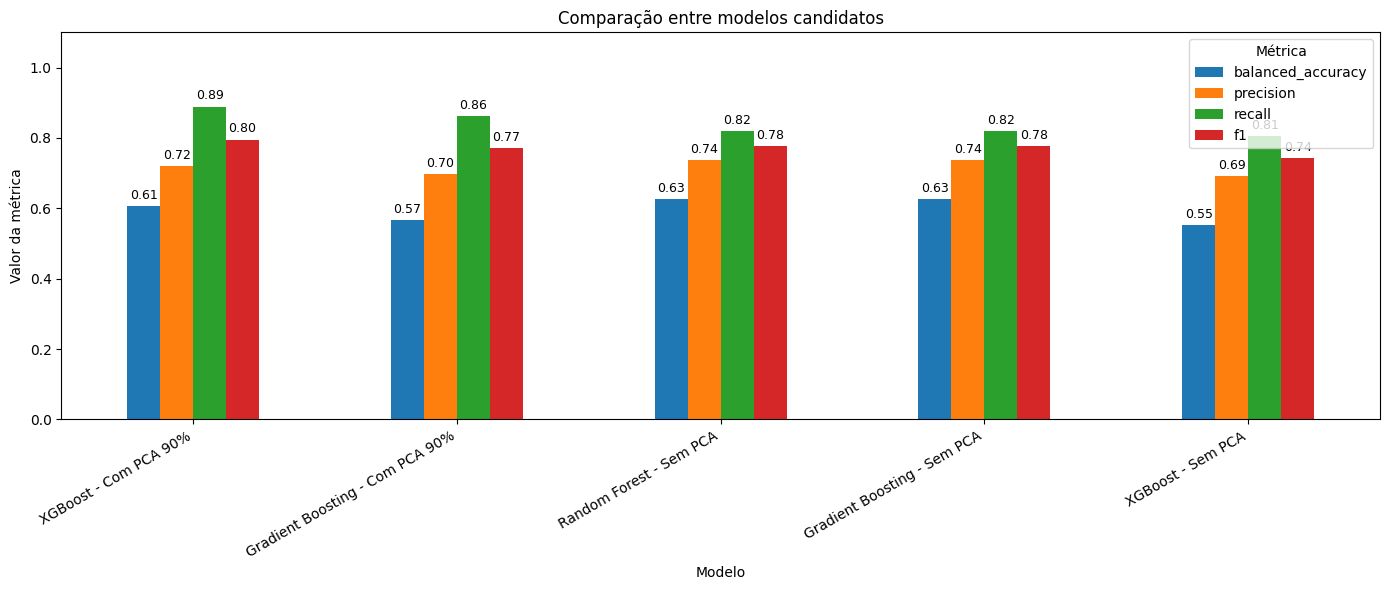

In [23]:
import matplotlib.pyplot as plt

metricas_plot = ["balanced_accuracy", "precision", "recall", "f1"]

df_plot = df_finalistas.copy()
df_plot["modelo_versao"] = df_plot["modelo"] + " - " + df_plot["versao"]

ax = df_plot.set_index("modelo_versao")[metricas_plot].plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Comparação entre modelos candidatos")
plt.ylabel("Valor da métrica")
plt.xlabel("Modelo")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1.10)
plt.legend(title="Métrica")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()